# Intrinsic exploration reward for MiniGrid

This notebook isolates map novelty as the only reward signal intended for later reinforcement learning:

\[
r_{\mathrm{explore}} = \beta \Delta N_{\mathrm{known}}.
\]

`PersistentMiniGridMapper` receives only local observations and action-based motion prediction. MiniGrid's hidden map dimensions are used solely to calculate diagnostic coverage; hidden state never affects actions or intrinsic reward.

## Imports

In [2]:
import gymnasium as gym
import minigrid
import matplotlib.pyplot as plt
import numpy as np

from utils.minigrid_mapper import PersistentMiniGridMapper

## Experiment configuration

The baseline uses random actions and a headless environment. Change `exploration_beta` later without modifying the mapper.

In [9]:
environment_id = "MiniGrid-DoorKey-8x8-v0"
num_baseline_episodes = 100
exploration_beta = 1.0
baseline_seed = 30_000
ascii_display_interval = 1
coverage_thresholds = (0.50, 0.75, 0.90)

## Intrinsic reward and statistics helpers

Reward calculation remains separate from mapping. Only `MappingUpdate.new_cells` contributes to reward; semantic discoveries, frontiers, environment reward, keys, doors, and goals add nothing.

In [4]:
def compute_exploration_reward(mapping_update, beta):
    """Reward only cells first discovered by the latest observation."""
    return float(beta * mapping_update.new_cells)


def mean_or_nan(values):
    """Return the mean of available values without empty-slice warnings."""
    values = np.asarray(values, dtype=float)
    finite_values = values[np.isfinite(values)]

    if finite_values.size == 0:
        return np.nan

    return float(np.mean(finite_values))


def format_optional_steps(value):
    """Format a threshold time that may never have been reached."""
    return "not reached" if np.isnan(value) else f"{value:.1f}"

## Random-action exploration baseline

Each episode creates a fresh mapper. The mapping update returned by `mapper.reset(observation)` establishes starting knowledge and is deliberately discarded for reward purposes. Exploration reward begins only after the first random action.

In [10]:
baseline_results = []
baseline_env = gym.make(environment_id)

try:
    for episode in range(num_baseline_episodes):
        episode_seed = baseline_seed + episode
        baseline_env.action_space.seed(episode_seed)
        observation, info = baseline_env.reset(seed=episode_seed)

        mapper = PersistentMiniGridMapper()
        initial_update = mapper.reset(observation)

        # Privileged dimensions are used only for diagnostic coverage.
        total_map_cells = (
            baseline_env.unwrapped.width
            * baseline_env.unwrapped.height
        )
        initial_coverage = len(mapper.cells) / total_map_cells

        episode_exploration_reward = 0.0
        episode_environment_reward = 0.0
        episode_steps = 0
        new_cells_per_step = []
        coverage_history = [initial_coverage]
        cumulative_reward_history = [0.0]
        steps_to_coverage = {
            threshold: (0.0 if initial_coverage >= threshold else np.nan)
            for threshold in coverage_thresholds
        }

        terminated = False
        truncated = False

        while not (terminated or truncated):
            action = baseline_env.action_space.sample()

            mapper.predict_action(action)
            (
                observation,
                environment_reward,
                terminated,
                truncated,
                info,
            ) = baseline_env.step(action)
            update = mapper.observe(observation)

            # This is the only reward intended for the later RL update.
            exploration_reward = compute_exploration_reward(
                update, exploration_beta
            )

            episode_steps += 1
            episode_exploration_reward += exploration_reward
            episode_environment_reward += environment_reward
            new_cells_per_step.append(update.new_cells)

            coverage = len(mapper.cells) / total_map_cells
            coverage_history.append(coverage)
            cumulative_reward_history.append(
                episode_exploration_reward
            )

            for threshold in coverage_thresholds:
                if (
                    np.isnan(steps_to_coverage[threshold])
                    and coverage >= threshold
                ):
                    steps_to_coverage[threshold] = float(episode_steps)

        new_cells_per_step = np.asarray(new_cells_per_step, dtype=int)
        final_known_cells = len(mapper.cells)
        final_coverage = final_known_cells / total_map_cells
        average_new_cells_per_step = (
            float(np.mean(new_cells_per_step))
            if episode_steps > 0
            else 0.0
        )
        zero_information_proportion = (
            float(np.mean(new_cells_per_step == 0))
            if episode_steps > 0
            else np.nan
        )

        baseline_results.append(
            {
                "episode": episode + 1,
                "episode_exploration_reward": (
                    episode_exploration_reward
                ),
                "episode_environment_reward": (
                    episode_environment_reward
                ),
                "episode_steps": episode_steps,
                "final_known_cells": final_known_cells,
                "final_coverage": final_coverage,
                "new_cells_per_step": new_cells_per_step,
                "average_new_cells_per_step": (
                    average_new_cells_per_step
                ),
                "zero_information_proportion": (
                    zero_information_proportion
                ),
                "steps_to_coverage": steps_to_coverage,
                "coverage_history": np.asarray(
                    coverage_history, dtype=float
                ),
                "cumulative_reward_history": np.asarray(
                    cumulative_reward_history, dtype=float
                ),
                "final_ascii_map": mapper.render_ascii(padding=0),
            }
        )

        if (episode + 1) % ascii_display_interval == 0:
            print(
                f"Episode {episode + 1:3d}/{num_baseline_episodes} | "
                f"coverage={final_coverage:.1%} | "
                f"intrinsic reward={episode_exploration_reward:.1f}"
            )
            print(mapper.render_ascii(padding=0))
            print()
finally:
    baseline_env.close()

Episode   1/100 | coverage=75.0% | intrinsic reward=36.0
######
#^...#
#....#
#....#
#....L
#....#
#K...#
######

Episode   2/100 | coverage=75.0% | intrinsic reward=33.0
######
#.K..#
#<...#
#....#
#....L
#....#
#....#
######

Episode   3/100 | coverage=75.0% | intrinsic reward=13.0
######
#....#
#....#
#....L
#....#
#..>.#
#..K.#
######

Episode   4/100 | coverage=37.5% | intrinsic reward=12.0
###
#.#
#.#
#K#
#.L
#.#
#v#
###

Episode   5/100 | coverage=95.3% | intrinsic reward=49.0
#####???
#.#..FF#
#.#....#
#.#....#
#KD....#
#>#....#
#.#...G#
########

Episode   6/100 | coverage=62.5% | intrinsic reward=15.0
#####
#...#
#...#
#.K.#
#...L
#...#
#.v.#
#####

Episode   7/100 | coverage=100.0% | intrinsic reward=46.0
########
#.#^...#
#.#....#
#.#...K#
#.#....#
#./....#
#.#...G#
########

Episode   8/100 | coverage=75.0% | intrinsic reward=30.0
######
#.^..#
#....#
#....#
#....#
#.K..L
#....#
######

Episode   9/100 | coverage=62.5% | intrinsic reward=12.0
#####
#...#
#..^#
#...L
#...#


## Baseline summary

In [6]:
final_coverages = np.asarray(
    [result["final_coverage"] for result in baseline_results]
)
exploration_rewards = np.asarray(
    [
        result["episode_exploration_reward"]
        for result in baseline_results
    ]
)
average_discovery_rates = np.asarray(
    [
        result["average_new_cells_per_step"]
        for result in baseline_results
    ]
)
zero_information_rates = np.asarray(
    [
        result["zero_information_proportion"]
        for result in baseline_results
    ]
)

average_threshold_steps = {
    threshold: mean_or_nan(
        [
            result["steps_to_coverage"][threshold]
            for result in baseline_results
        ]
    )
    for threshold in coverage_thresholds
}
threshold_reach_rates = {
    threshold: np.mean(
        [
            np.isfinite(result["steps_to_coverage"][threshold])
            for result in baseline_results
        ]
    )
    for threshold in coverage_thresholds
}

print("Random exploration baseline")
print("Environment:", environment_id)
print("Episodes:", num_baseline_episodes)
print(f"Exploration beta: {exploration_beta:.3f}")
print(f"Average final map coverage: {np.mean(final_coverages):.2%}")
print(f"Average exploration reward: {np.mean(exploration_rewards):.2f}")
print(
    f"Average new cells per step: "
    f"{np.mean(average_discovery_rates):.4f}"
)

for threshold in coverage_thresholds:
    average_steps = average_threshold_steps[threshold]
    reach_rate = threshold_reach_rates[threshold]
    print(
        f"Average steps to {threshold:.0%} coverage: "
        f"{format_optional_steps(average_steps)} "
        f"(reached in {reach_rate:.1%} of episodes)"
    )

print(
    f"Average proportion of zero-information steps: "
    f"{np.mean(zero_information_rates):.2%}"
)
print(
    f"Average external environment reward (diagnostic only): "
    f"{np.mean([r['episode_environment_reward'] for r in baseline_results]):.4f}"
)

Random exploration baseline
Environment: MiniGrid-DoorKey-8x8-v0
Episodes: 100
Exploration beta: 1.000
Average final map coverage: 64.66%
Average exploration reward: 24.75
Average new cells per step: 0.0405
Average steps to 50% coverage: 44.9 (reached in 80.0% of episodes)
Average steps to 75% coverage: 135.7 (reached in 43.0% of episodes)
Average steps to 90% coverage: 332.7 (reached in 15.0% of episodes)
Average proportion of zero-information steps: 99.51%
Average external environment reward (diagnostic only): 0.0122


## Representative random-exploration episode

The episode whose final coverage is closest to the median is plotted to avoid selecting only the best or worst random trajectory. Coverage includes the initial map as starting knowledge; cumulative intrinsic reward starts at zero and increases only after actions reveal new cells.

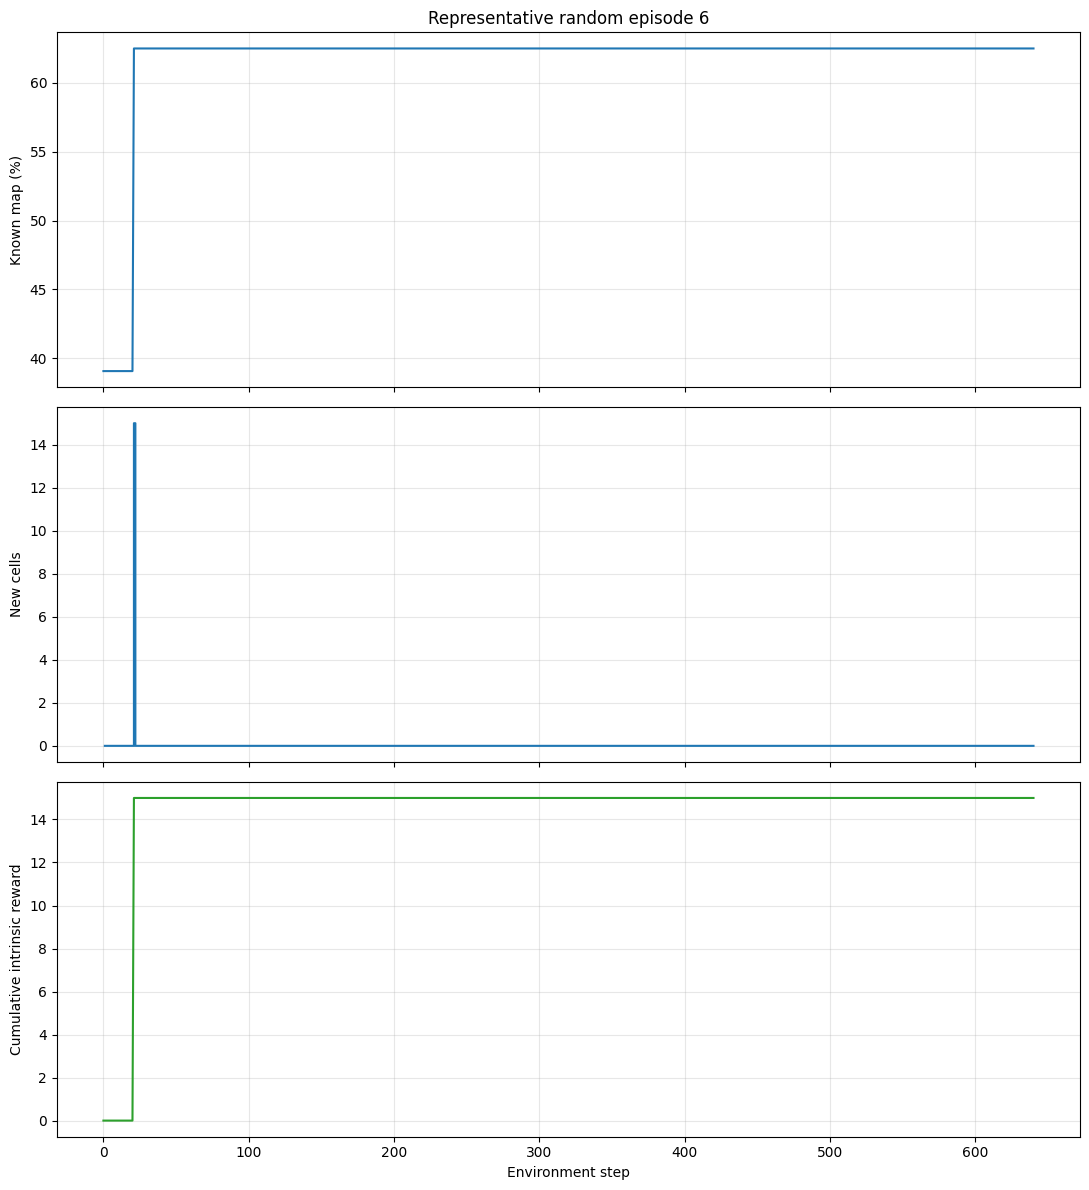

Final ASCII map for the representative episode:
#####
#...#
#...#
#.K.#
#...L
#...#
#.v.#
#####


In [7]:
median_coverage = np.median(final_coverages)
representative_index = int(
    np.argmin(np.abs(final_coverages - median_coverage))
)
representative = baseline_results[representative_index]

coverage_steps = np.arange(len(representative["coverage_history"]))
action_steps = np.arange(
    1, len(representative["new_cells_per_step"]) + 1
)

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

axes[0].plot(
    coverage_steps,
    100.0 * representative["coverage_history"],
)
axes[0].set_ylabel("Known map (%)")
axes[0].set_title(
    f"Representative random episode {representative['episode']}"
)
axes[0].grid(alpha=0.3)

axes[1].step(
    action_steps,
    representative["new_cells_per_step"],
    where="post",
)
axes[1].set_ylabel("New cells")
axes[1].grid(alpha=0.3)

axes[2].plot(
    coverage_steps,
    representative["cumulative_reward_history"],
    color="tab:green",
)
axes[2].set_xlabel("Environment step")
axes[2].set_ylabel("Cumulative intrinsic reward")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Final ASCII map for the representative episode:")
print(representative["final_ascii_map"])